## Driver TFs Evaluations

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
from numba.core.errors import NumbaDeprecationWarning
warnings.simplefilter("ignore", category=NumbaDeprecationWarning)
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

In [3]:
import os
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import scanpy as sc
import decoupler as dc

In [5]:
import scmagnify as scm
from scmagnify.settings import settings
import scmagnify.logging as logg

In [6]:
sys.path.append("/home/chenxufeng/WorkSpace/scMagnify/src/")
from grn_tools import GRNEvaluator, METHOD_PALETTE_CISTROME, DIRPJTHOMES

## Configurations

In [8]:
%matplotlib inline

scm.load_fonts(["Arial"])

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "Arial"
plt.rcParams["image.cmap"] = "Spectral_r"

# For saving vector graphics
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["text.usetex"] = False

In [9]:
fig_dir = "../figures/Fig2/" 
if not os.path.exists(fig_dir):
    os.makedirs(fig_dir)
data_dir = "../data/Fig2/"
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

In [10]:
trail_id = "250423"

t_cell_home = DIRPJTHOMES["PMID36973557_NatBiotechnol2023_T-cell-depleted"]
cd34_home = DIRPJTHOMES["PMID36973557_NatBiotechnol2023_CD34"]

t_cell_net = f"{t_cell_home}/benchmark/{trail_id}/net/"
cd34_net = f"{cd34_home}/benchmark/{trail_id}/net/"

## GRNEvaluator

In [11]:
geval = GRNEvaluator()

### Basic Settings

In [12]:
algos = ["Dictys", "FigR", "Pando", "CellOracle", "SCENIC", "Velorama", "GRNBoost2", "SINCERITIES", "LINGER", "scMagnify"]
regex_pattern = "|".join(algos)

In [13]:
import scmagnify as scm
scm_dir = os.path.dirname(scm.__file__)
human_tf_file = os.path.join(scm_dir, "data", "tf_lists", f"allTFs_hg38.txt")
tf_list = pd.read_csv(human_tf_file, header=None)[0].tolist()

tcell_gene_list = pd.read_csv(f"{t_cell_home}/benchmark/gene_list/test_assoc_fdr1e-3_A0.3.csv", header=None)[0].tolist()
cd34_gene_list = pd.read_csv(f"{cd34_home}/benchmark/gene_list/test_assoc_fdr1e-3_A0.3.csv", header=None)[0].tolist()

### Load GRN Networks

In [14]:
geval.load_grns(t_cell_net, 
                dataset="PMID36973557_NatBiotechnol2023_T-cell-depleted",
                regex=regex_pattern,
                tf_filter=list(set(tf_list) & set(tcell_gene_list)))

🔍 Regex filter 'Dictys|FigR|Pando|CellOracle|SCENIC|Velorama|GRNBoost2|SINCERITIES|LINGER|scMagnify' matched 33 
out of 72 files.

Output()

✅Scan complete. Loaded 33 networks from 
'/home/chenxufeng/picb_cxf/Data/PMID36973557_NatBiotechnol2023_T-cell-depleted//benchmark/250423/net/'.

In [15]:
geval.load_grns(cd34_net, 
                dataset="PMID36973557_NatBiotechnol2023_CD34",
                regex=regex_pattern, 
                tf_filter=list(set(tf_list) & set(cd34_gene_list)))

🔍 Regex filter 'Dictys|FigR|Pando|CellOracle|SCENIC|Velorama|GRNBoost2|SINCERITIES|LINGER|scMagnify' matched 66 
out of 144 files.

Output()

✅Scan complete. Loaded 66 networks from 
'/home/chenxufeng/picb_cxf/Data/PMID36973557_NatBiotechnol2023_CD34//benchmark/250423/net/'.

In [16]:
geval.calculate_network_score()

Output()

✅ Network scoring complete.

### Driver TFs Gene Set

In [16]:
drive_tfs_dict = {
    "NaiveB": ["PAX5", "EBF1", "TCF3", "IKZF1", "SPIB", "POU2F2", "FOXO1", "IRF4", "SOX4", "MEF2C"],
    "Mono":   ["SPI1", "CEBPA", "IRF8", "KLF4", "MAFB", "CEBPB", "IRF5", "NR4A1", "CUX1", "EGR2"],
    "Ery":    ["GATA1", "ZFPM1", "GFI1B", "KLF1", "SPI1", "GATA2", "LDB1", "TAL1", "ZFPM1"],
    "pDC":  ["TCF4", "SPIB", "IRF8", "RUNX2", "IRF7", "IRF5", "IKZF1", "E2-2"],
    "cDC":  ["IRF8", "BATF3", "IRF4", "SPI1", "CEBPA", "CEBPB", "KLF4", "RUNX1"],
    "Mega": ["GATA1", "TAL1", "KLF1", "NFE2", "GFI1B", "MEIS1", "RUNX1"],
    "CLP":    ["IKZF1", "SPI1", "EBF1", "TCF3", "STAT5", "RUNX1"] 
}

In [21]:
# A new dictionary of lineage-driving transcription factors based on the provided image.
drive_tfs_dict = {
    "NaiveB": ["PAX5", "EBF1", "TCF3", "IKZF1", "SPIB", "POU2F2", "FOXO1", "IRF4", "SOX4", "MEF2C"],
    "Mono": ["SPI1", "CEBPA", "IRF8", "KLF4", "MAFB", "CEBPB", "EGR1", "FOS", "JUN", "FOSB"],
    "Ery": ["GATA1", "ZFPM1", "GFI1B", "KLF1", "BCL11A", "GATA2", "LDB1", "TAL1", "NFE2", "KLF3"],
    "pDC":  ["TCF4", "SPIB", "IRF8", "IRF7", "IKZF1"],
    "cDC":  ["IRF8", "BATF3", "IRF4", "SPI1", "CEBPA", "CEBPB"],
    "Mega": ["GATA1", "TAL1", "FLI1", "NFE2", "GFI1B", "MEIS1"],
    "CLP": ["IKZF1", "SPI1", "EBF1", "TCF3", "STAT5", "RUNX1"] 
}

🔬 Filtering ground truth TFs to include only those present in the networks' TF universe...
📊 Filtering complete. TF counts per lineage (Original -> Filtered):
  - NaiveB: 10 -> 10
  - Mono: 10 -> 9
  - Ery: 10 -> 6
  - pDC: 5 -> 5
  - cDC: 6 -> 5
  - Mega: 6 -> 4
  - CLP: 6 -> 5


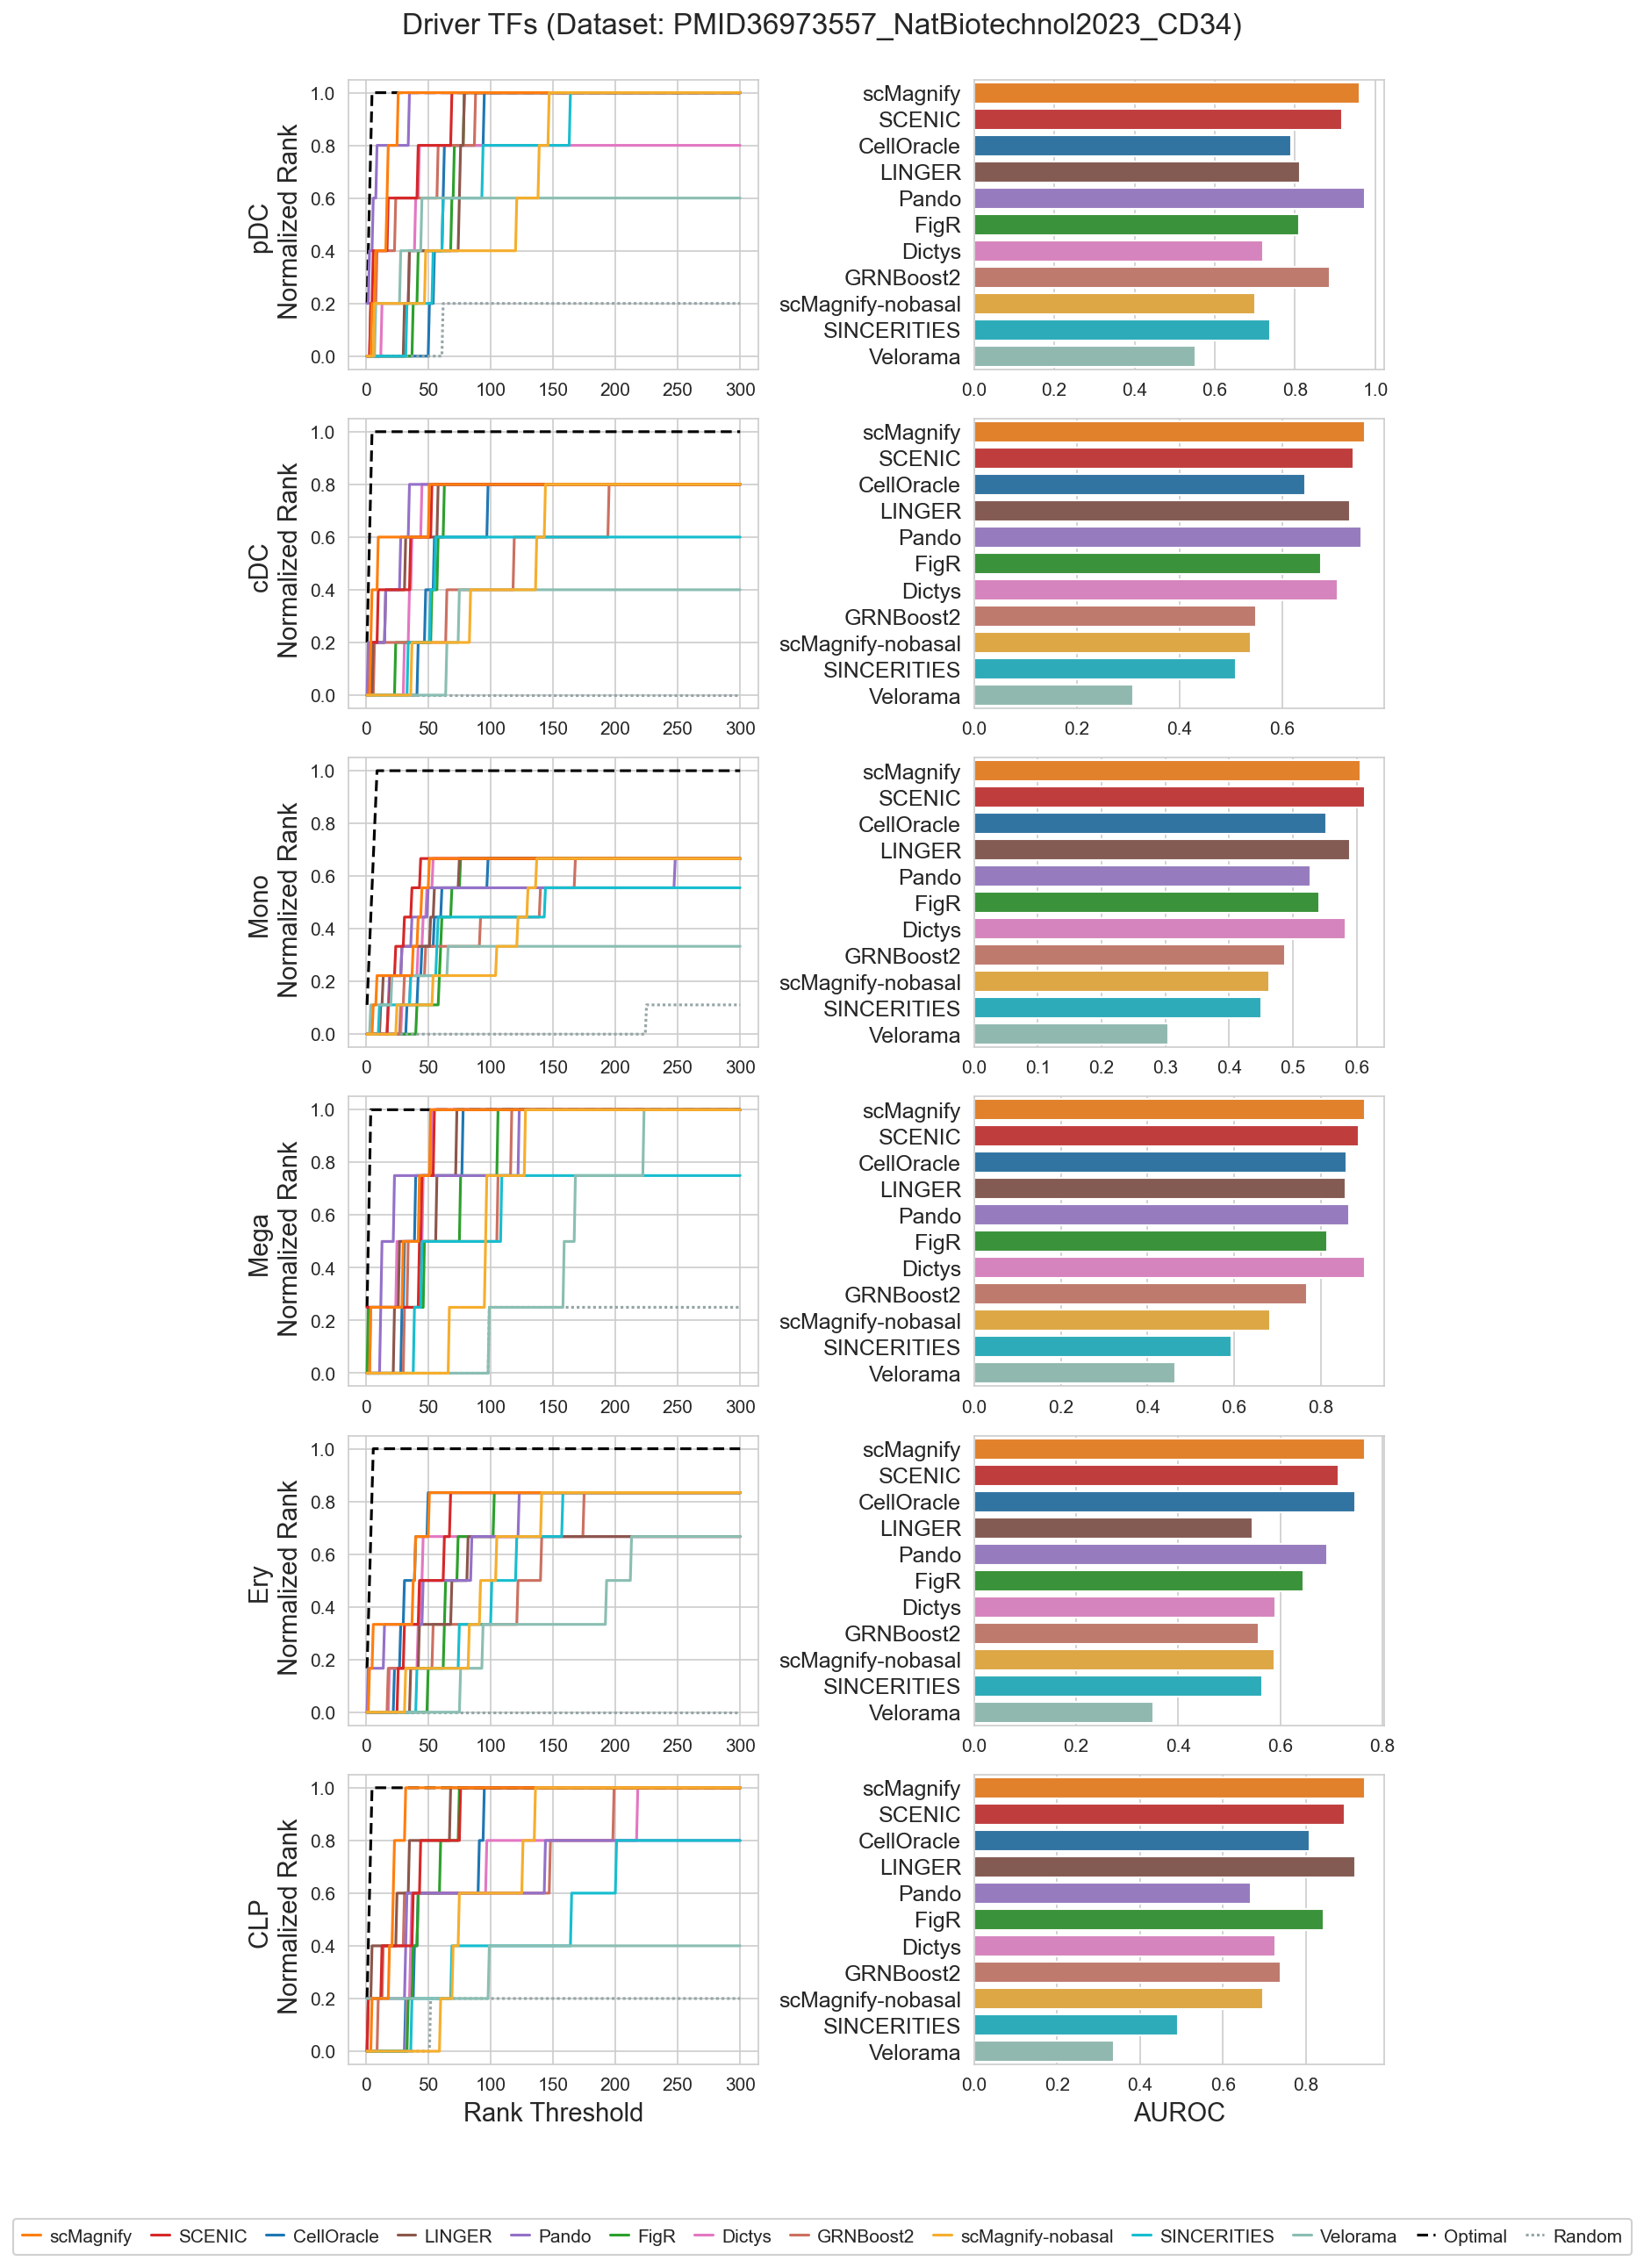

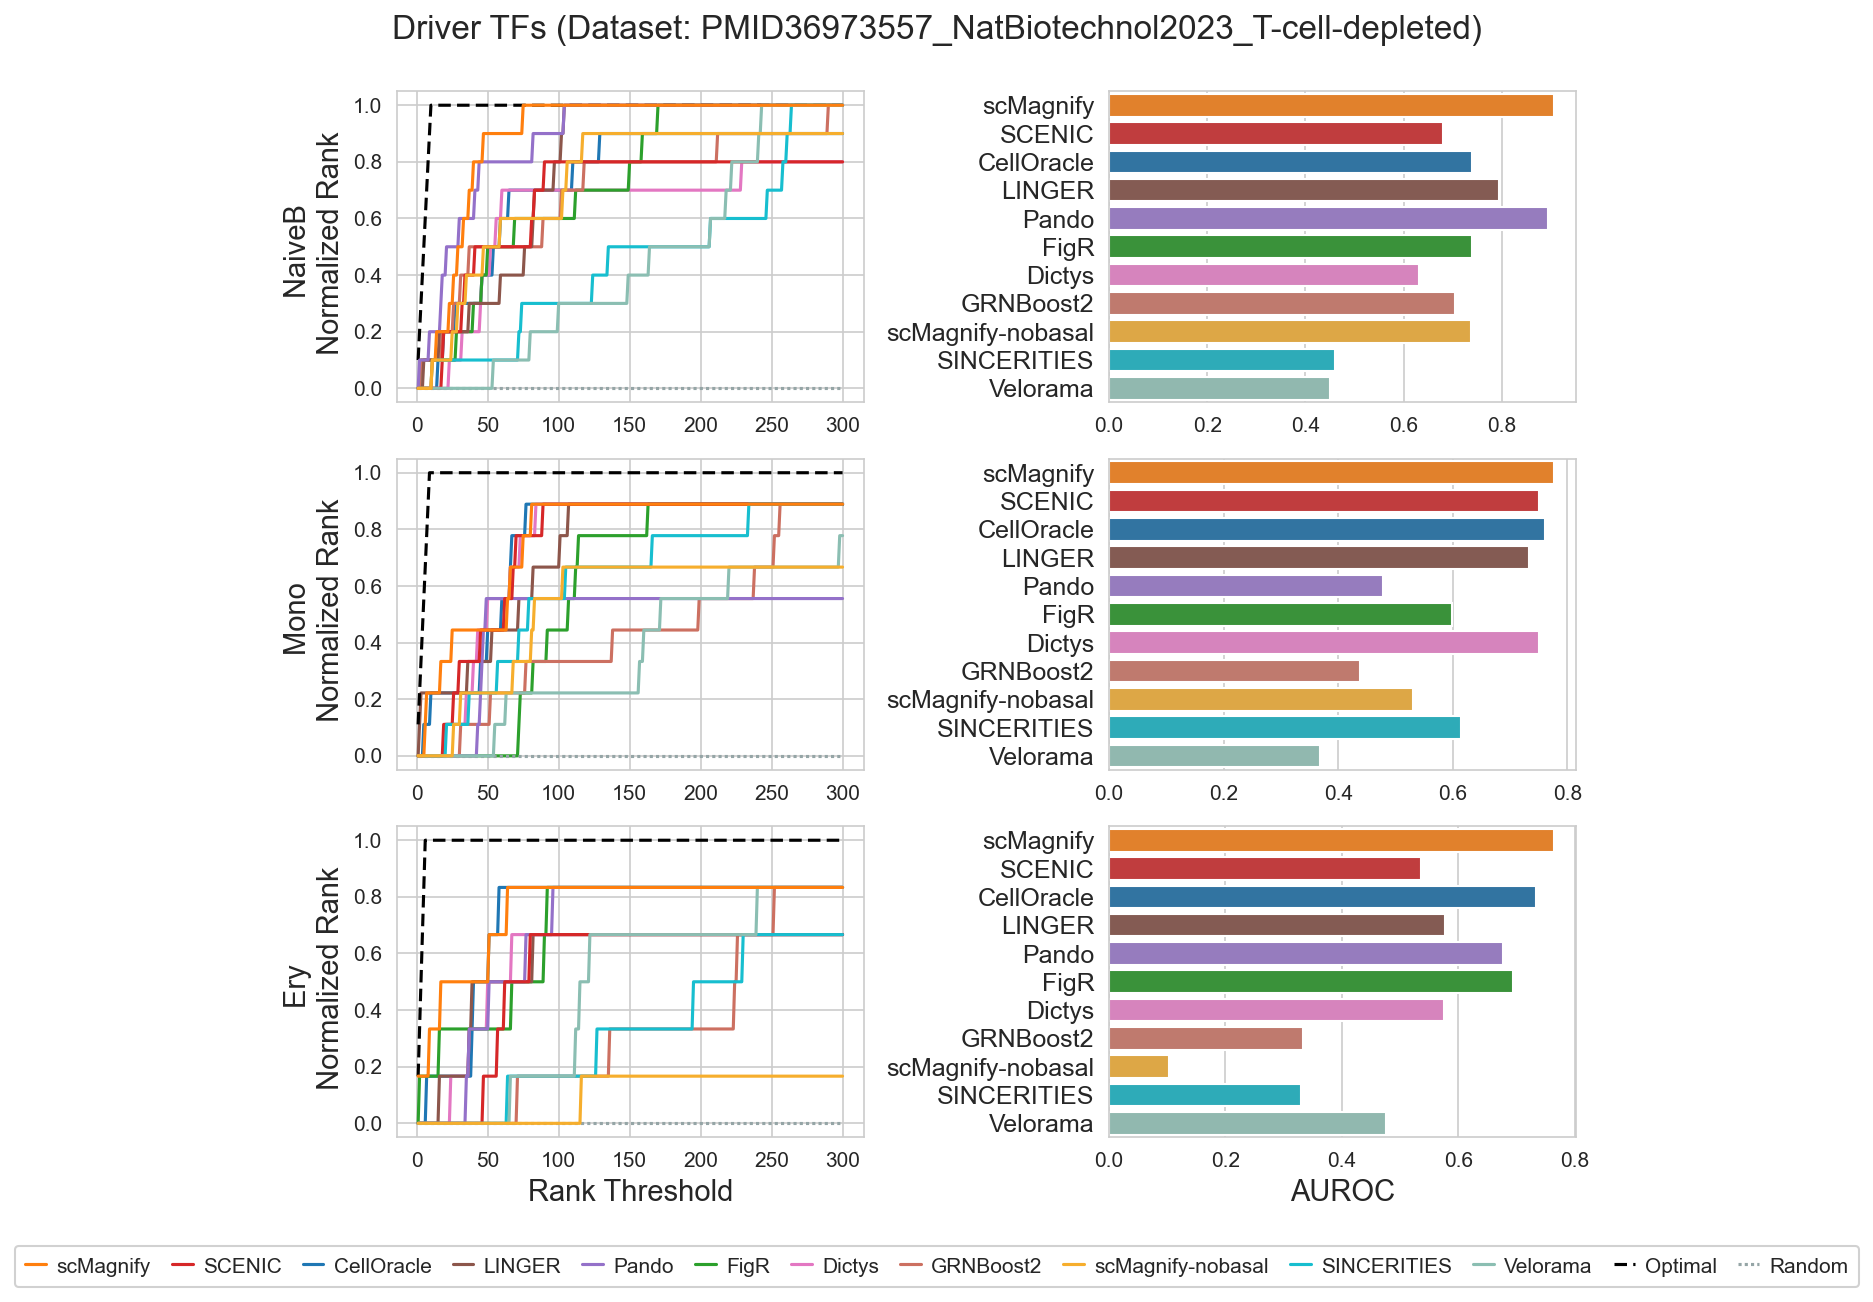

In [22]:
tf_recovery_df = geval.calculate_tf_recovery(
    tf_regulators_dict = drive_tfs_dict,
    ranking_metric = "degree_centrality",
    plot=True,
    rank_threshold=300,
    filter_tfs_in_networks=True
)

2025-10-19 14:32:58 | [INFO] maxp pruned
2025-10-19 14:32:58 | [INFO] LTSH dropped
2025-10-19 14:32:58 | [INFO] cmap pruned
2025-10-19 14:32:58 | [INFO] kern pruned
2025-10-19 14:32:58 | [INFO] post pruned
2025-10-19 14:32:58 | [INFO] PCLT dropped
2025-10-19 14:32:58 | [INFO] DSIG dropped
2025-10-19 14:32:58 | [INFO] glyf pruned
2025-10-19 14:32:58 | [INFO] Added gid0 to subset
2025-10-19 14:32:58 | [INFO] Added first four glyphs to subset
2025-10-19 14:32:58 | [INFO] Closing glyph list over 'glyf': 46 glyphs before
2025-10-19 14:32:58 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'period', 'r', 's', 'space', 't', 'two', 'v', 'y', 'z', 'zero']
2025-10-19 14:32:58 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 21, 24, 36, 37, 38, 39, 40, 41, 42, 44, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 68, 69, 70,

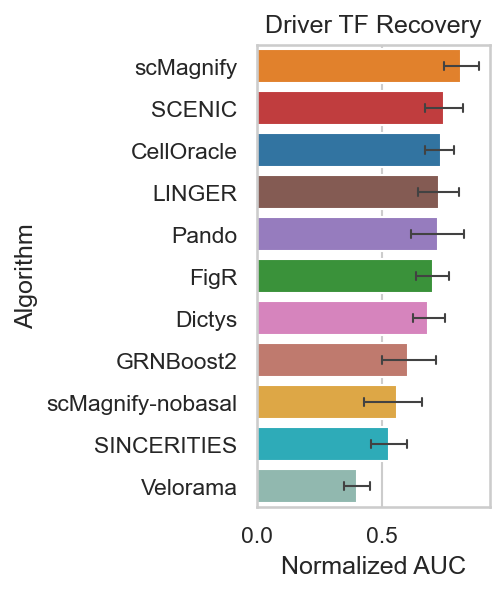

In [24]:
# 1. Filter the DataFrame to exclude 'Random' and 'Optimal' algorithms.
df_filtered = geval.rank_auc.query("Algorithm != 'Random' and Algorithm != 'Optimal'")

# 2. Calculate the median 'Normalized AUC' for each algorithm.
#    Then, sort these values in descending order and get the algorithm names (the index).
#    This list of names will be our desired order for the plot.
median_sorted_algs = (
    df_filtered.groupby('Algorithm')['Normalized AUC']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 3. Create the color palette based on the new sorted order of algorithms.
custom_palette = [METHOD_PALETTE_CISTROME[alg] for alg in median_sorted_algs]

# 4. Create the bar plot.
#    - Use the 'order' parameter to apply the sorting.
#    - Use the 'estimator' parameter to make the bars represent the median,
#      which is consistent with the sorting logic.

with sns.plotting_context("notebook", font_scale=1):
    plt.figure(figsize=(2, 4))
    plt.title("Driver TF Recovery")
    sns.barplot(
        data=df_filtered,
        x="Normalized AUC",
        y="Algorithm",
        order=median_sorted_algs,
        palette=custom_palette,
        err_kws={"linewidth": 1},
        capsize=0.2,
        estimator=np.mean,
    )
plt.savefig(os.path.join(fig_dir, "Fig2e-TF-recovery_normAUC.pdf"), bbox_inches="tight", dpi=300)

2025-10-09 13:35:37 | [INFO] maxp pruned
2025-10-09 13:35:37 | [INFO] LTSH dropped
2025-10-09 13:35:37 | [INFO] cmap pruned
2025-10-09 13:35:37 | [INFO] kern pruned
2025-10-09 13:35:37 | [INFO] post pruned
2025-10-09 13:35:37 | [INFO] PCLT dropped
2025-10-09 13:35:37 | [INFO] DSIG dropped
2025-10-09 13:35:37 | [INFO] glyf pruned
2025-10-09 13:35:37 | [INFO] Added gid0 to subset
2025-10-09 13:35:37 | [INFO] Added first four glyphs to subset
2025-10-09 13:35:37 | [INFO] Closing glyph list over 'glyf': 46 glyphs before
2025-10-09 13:35:37 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'period', 'r', 's', 'space', 't', 'two', 'v', 'y', 'z', 'zero']
2025-10-09 13:35:37 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 21, 24, 36, 37, 38, 39, 40, 41, 42, 44, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 68, 69, 70,

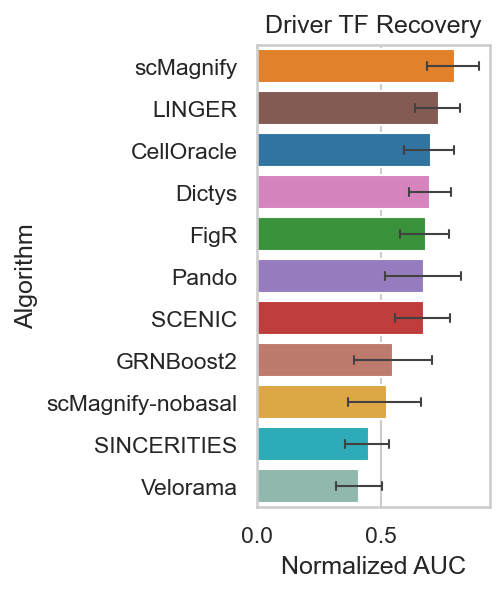

In [18]:
# 1. Filter the DataFrame to exclude 'Random' and 'Optimal' algorithms.
df_filtered = geval.rank_auc.query("Algorithm != 'Random' and Algorithm != 'Optimal'")

# 2. Calculate the median 'Normalized AUC' for each algorithm.
#    Then, sort these values in descending order and get the algorithm names (the index).
#    This list of names will be our desired order for the plot.
median_sorted_algs = (
    df_filtered.groupby('Algorithm')['Normalized AUC']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 3. Create the color palette based on the new sorted order of algorithms.
custom_palette = [METHOD_PALETTE_CISTROME[alg] for alg in median_sorted_algs]

# 4. Create the bar plot.
#    - Use the 'order' parameter to apply the sorting.
#    - Use the 'estimator' parameter to make the bars represent the median,
#      which is consistent with the sorting logic.

with sns.plotting_context("notebook", font_scale=1):
    plt.figure(figsize=(2, 4))
    plt.title("Driver TF Recovery")
    sns.barplot(
        data=df_filtered,
        x="Normalized AUC",
        y="Algorithm",
        order=median_sorted_algs,
        palette=custom_palette,
        err_kws={"linewidth": 1},
        capsize=0.2,
        estimator=np.mean,
    )
plt.savefig(os.path.join(fig_dir, "Fig2e-TF-recovery_normAUC.pdf"), bbox_inches="tight", dpi=300)

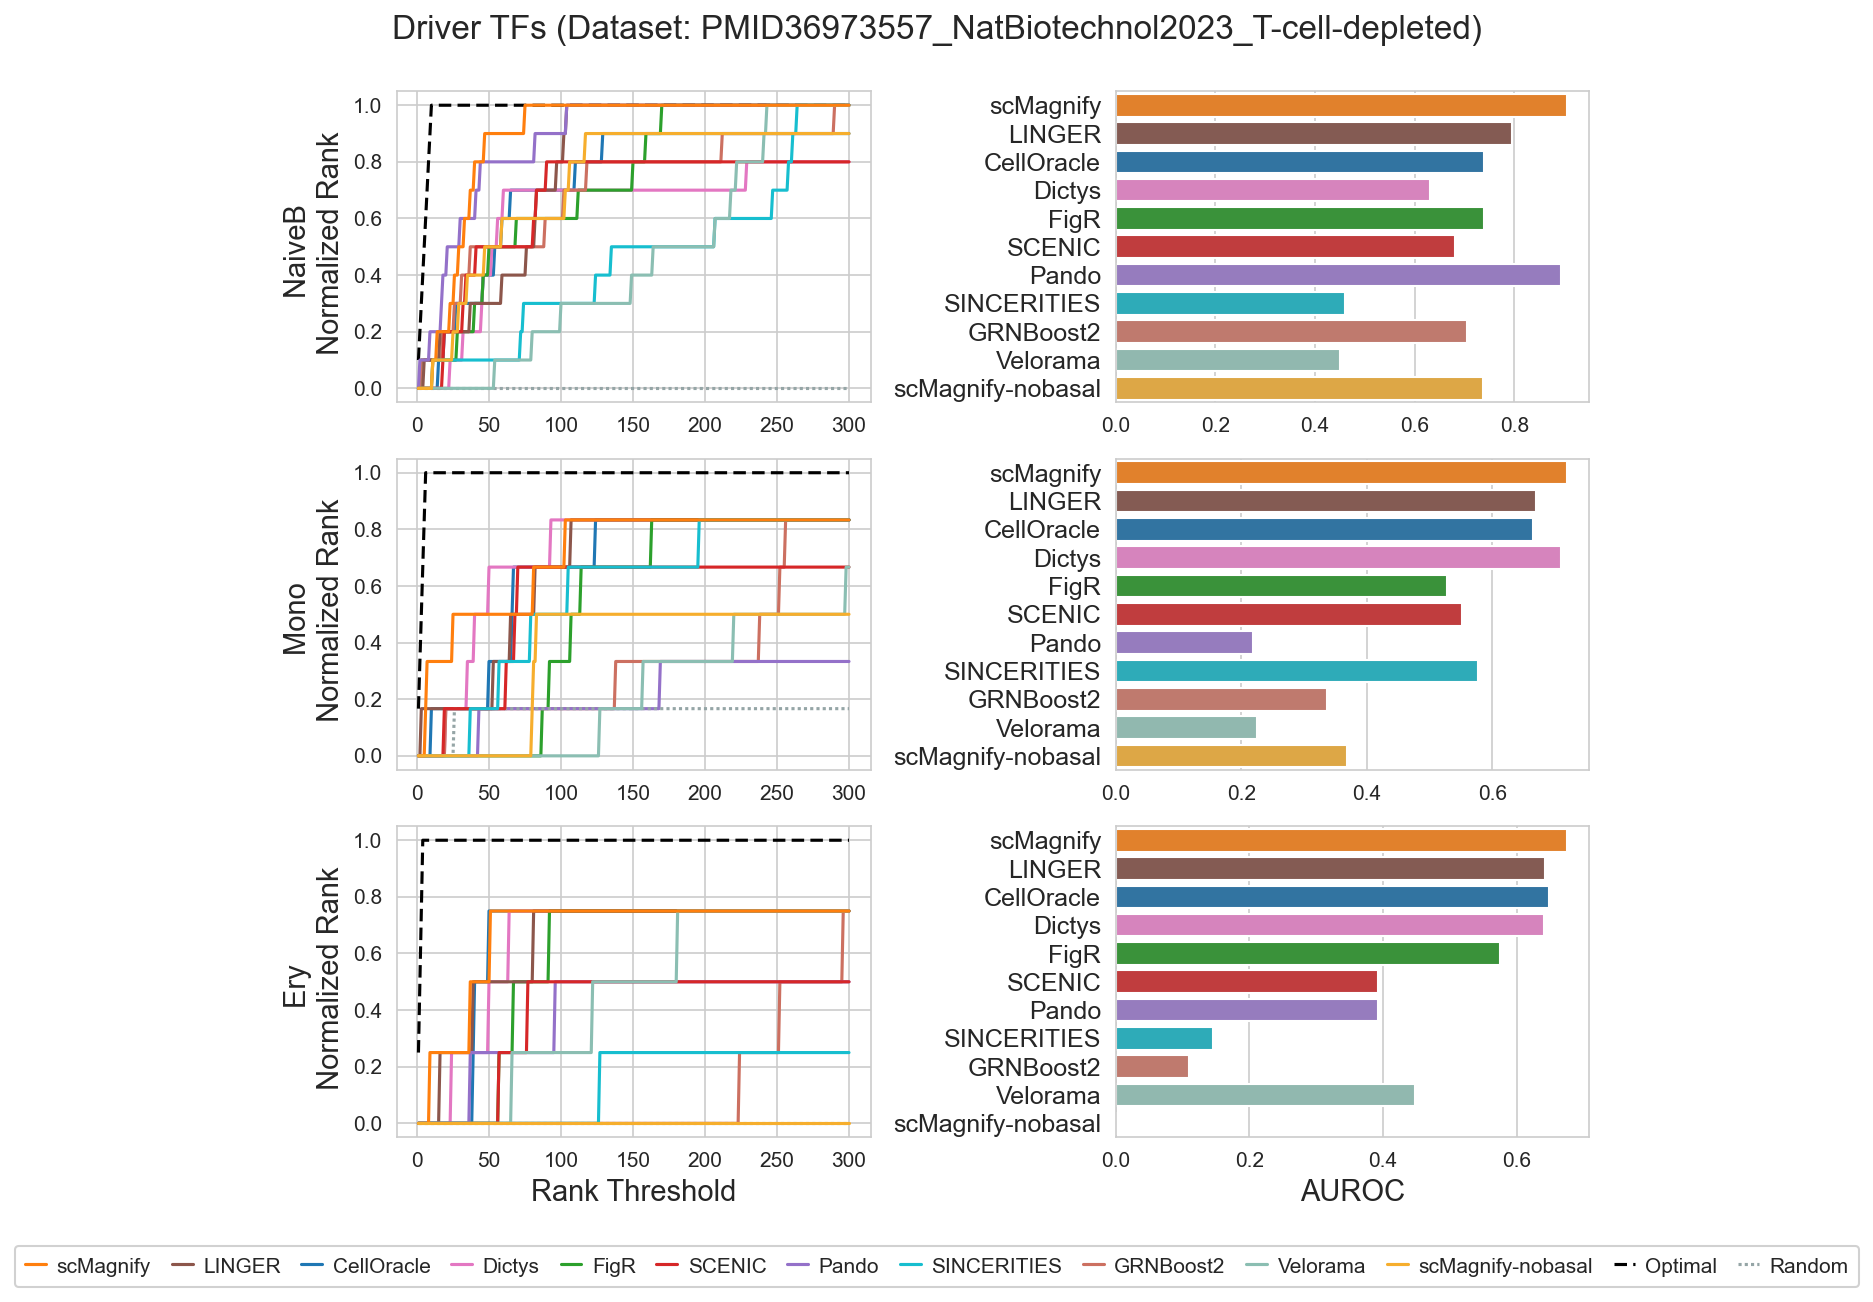

2025-10-09 13:35:54 | [INFO] maxp pruned
2025-10-09 13:35:54 | [INFO] LTSH dropped
2025-10-09 13:35:54 | [INFO] cmap pruned
2025-10-09 13:35:54 | [INFO] kern pruned
2025-10-09 13:35:54 | [INFO] post pruned
2025-10-09 13:35:54 | [INFO] PCLT dropped
2025-10-09 13:35:54 | [INFO] DSIG dropped
2025-10-09 13:35:54 | [INFO] glyf pruned
2025-10-09 13:35:54 | [INFO] Added gid0 to subset
2025-10-09 13:35:54 | [INFO] Added first four glyphs to subset
2025-10-09 13:35:54 | [INFO] Closing glyph list over 'glyf': 59 glyphs before
2025-10-09 13:35:54 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'a', 'b', 'c', 'colon', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'v', 'y', 'z', 'zero']
2025-10-09 13:35:54 | [INFO] Glyph IDs:  

💾 Saved TF recovery plot for dataset 'PMID36973557_NatBiotechnol2023_T-cell-depleted' to: ../figures/Fig2/Fig2f-tf_recovery_tcell.pdf


In [19]:
geval.plot_tf_recovery(
    geval.rank_cdf.query("Dataset == 'PMID36973557_NatBiotechnol2023_T-cell-depleted'"),
    geval.rank_auc.query("Dataset == 'PMID36973557_NatBiotechnol2023_T-cell-depleted'"),
    save=os.path.join(fig_dir, "Fig2f-tf_recovery_tcell.pdf")
)

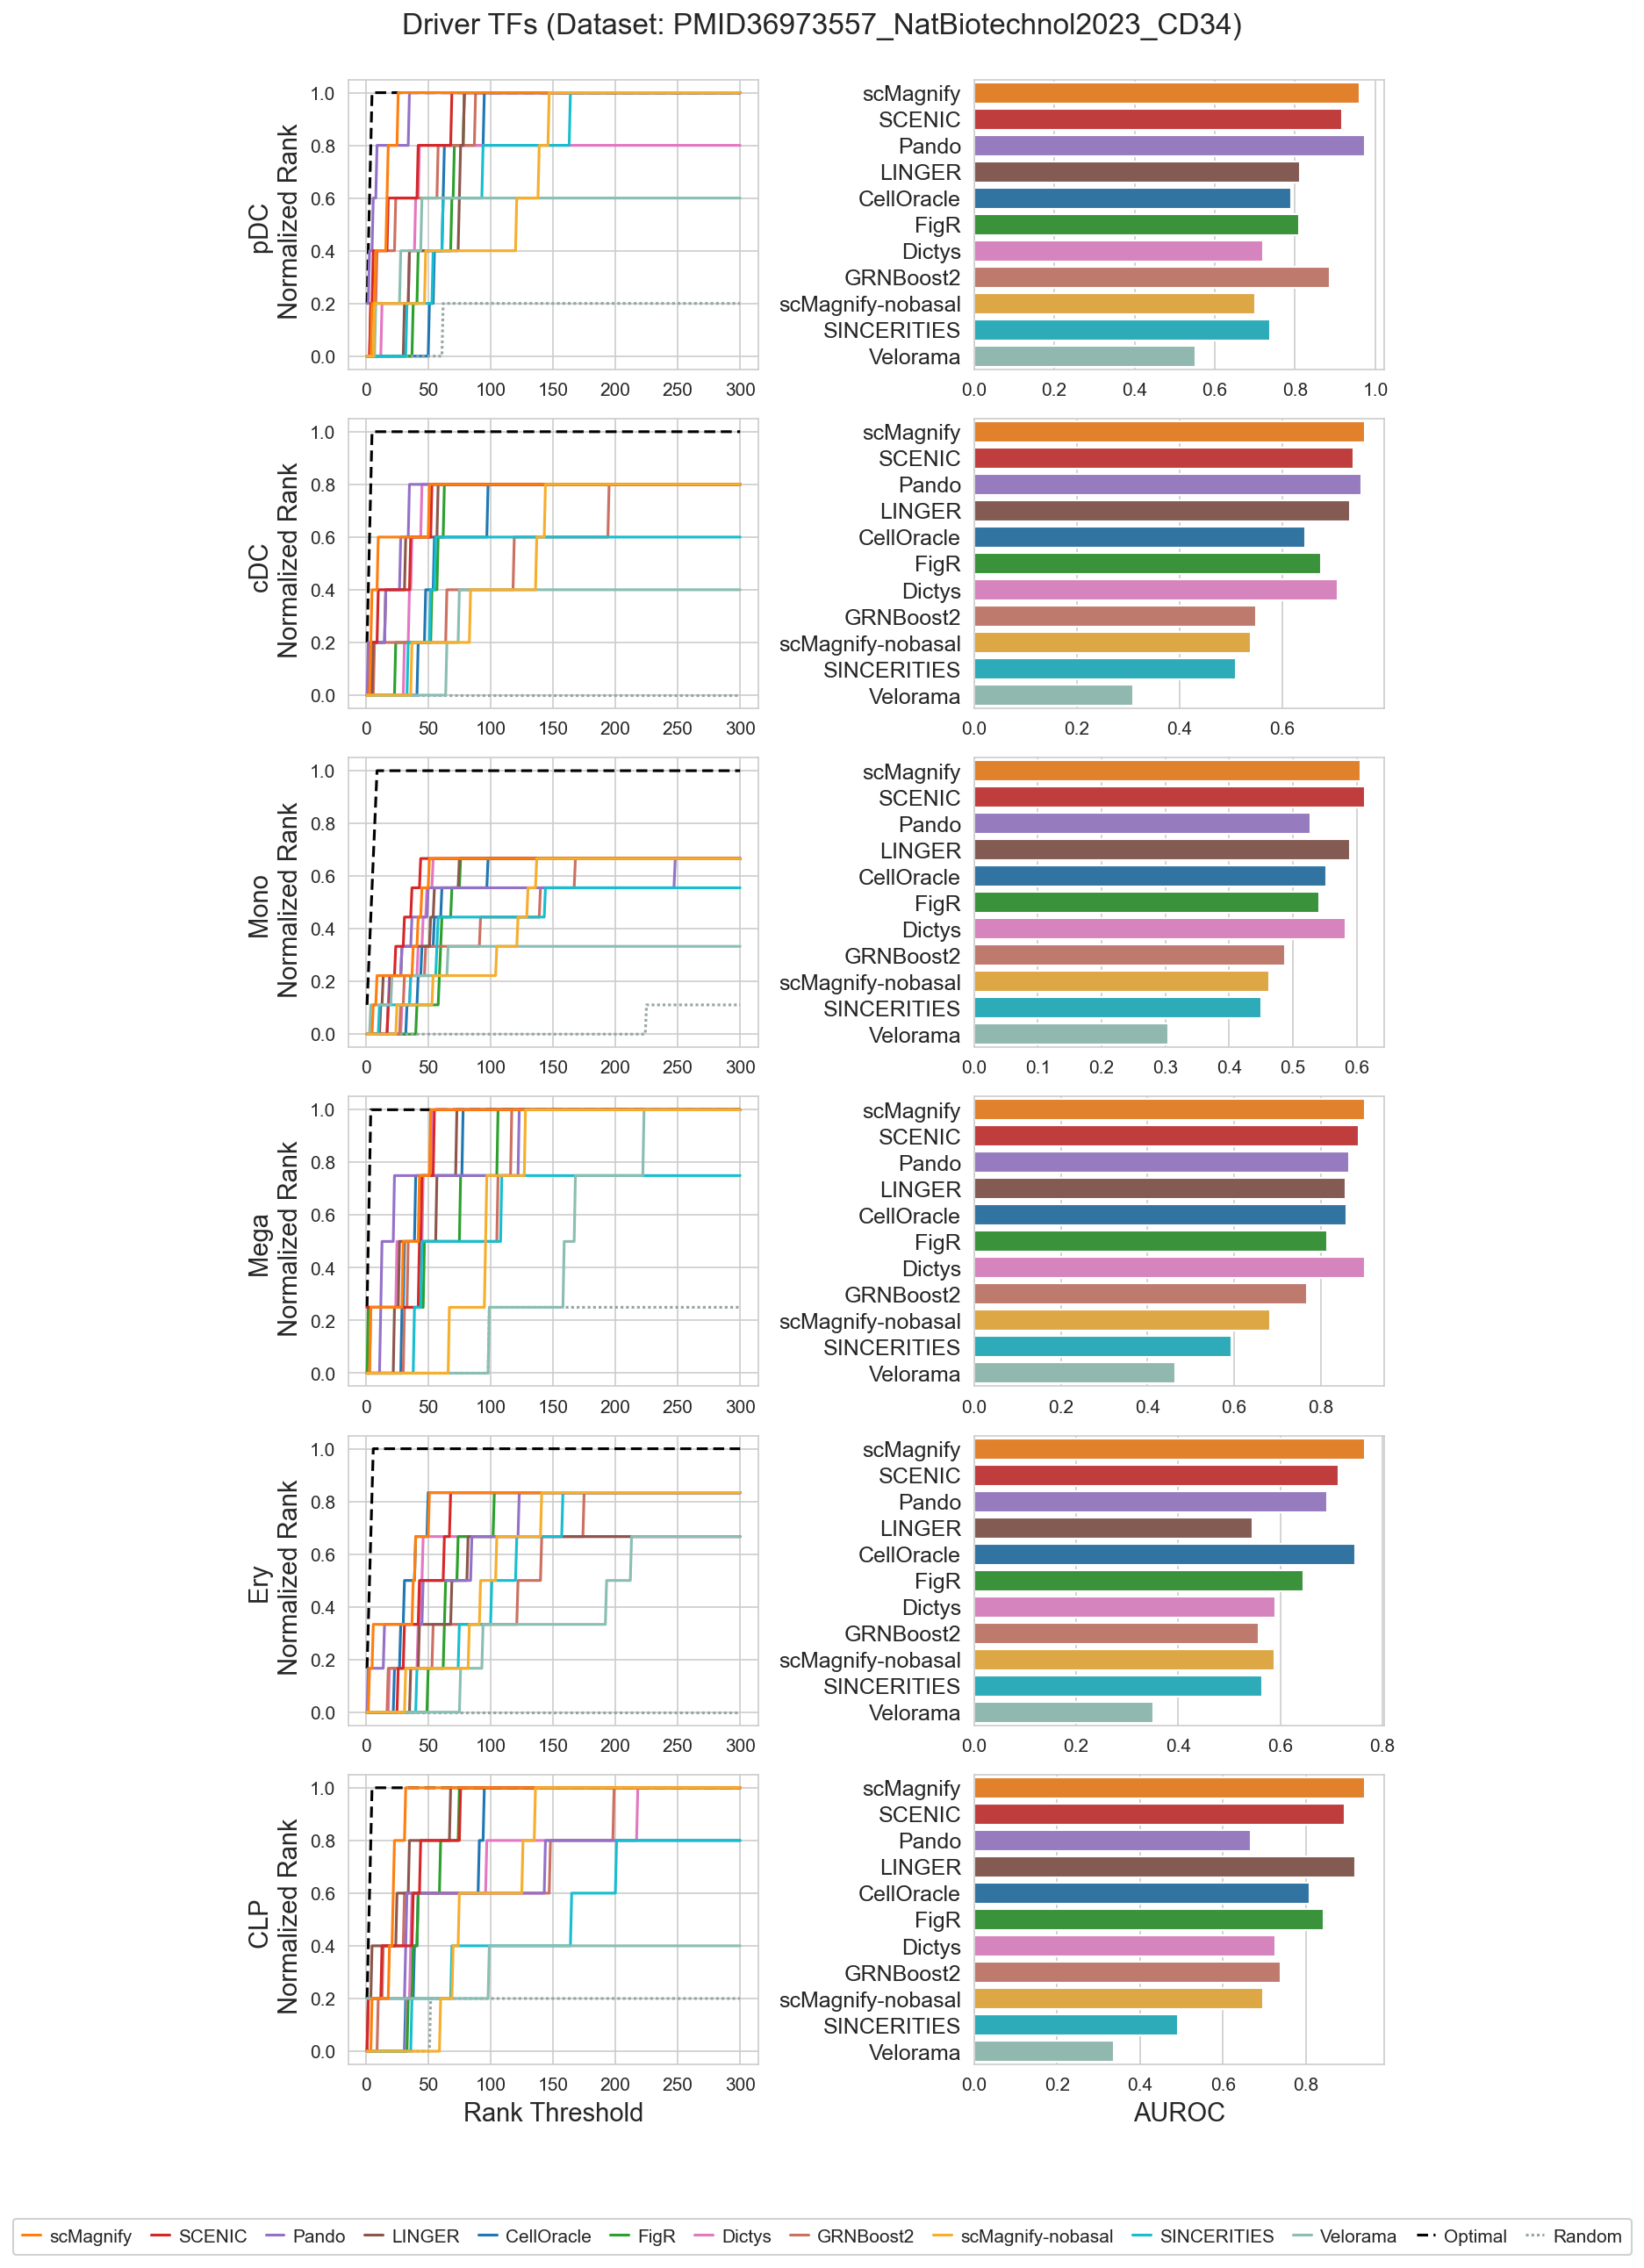

2025-10-19 14:37:16 | [INFO] maxp pruned
2025-10-19 14:37:16 | [INFO] LTSH dropped
2025-10-19 14:37:16 | [INFO] cmap pruned
2025-10-19 14:37:16 | [INFO] kern pruned
2025-10-19 14:37:16 | [INFO] post pruned
2025-10-19 14:37:16 | [INFO] PCLT dropped
2025-10-19 14:37:16 | [INFO] DSIG dropped
2025-10-19 14:37:16 | [INFO] glyf pruned
2025-10-19 14:37:16 | [INFO] Added gid0 to subset
2025-10-19 14:37:16 | [INFO] Added first four glyphs to subset
2025-10-19 14:37:16 | [INFO] Closing glyph list over 'glyf': 59 glyphs before
2025-10-19 14:37:16 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'a', 'b', 'c', 'colon', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'v', 'y', 'z', 'zero']
2025-10-19 14:37:16 | [INFO] Glyph IDs:  

💾 Saved TF recovery plot for dataset 'PMID36973557_NatBiotechnol2023_CD34' to: ../figures/Fig2/SupFig4-tf_recovery_cd34.pdf


In [25]:
geval.plot_tf_recovery(
    geval.rank_cdf.query("Dataset == 'PMID36973557_NatBiotechnol2023_CD34'"),
    geval.rank_auc.query("Dataset == 'PMID36973557_NatBiotechnol2023_CD34'"),
    save=os.path.join(fig_dir, "SupFig4-tf_recovery_cd34.pdf")
)

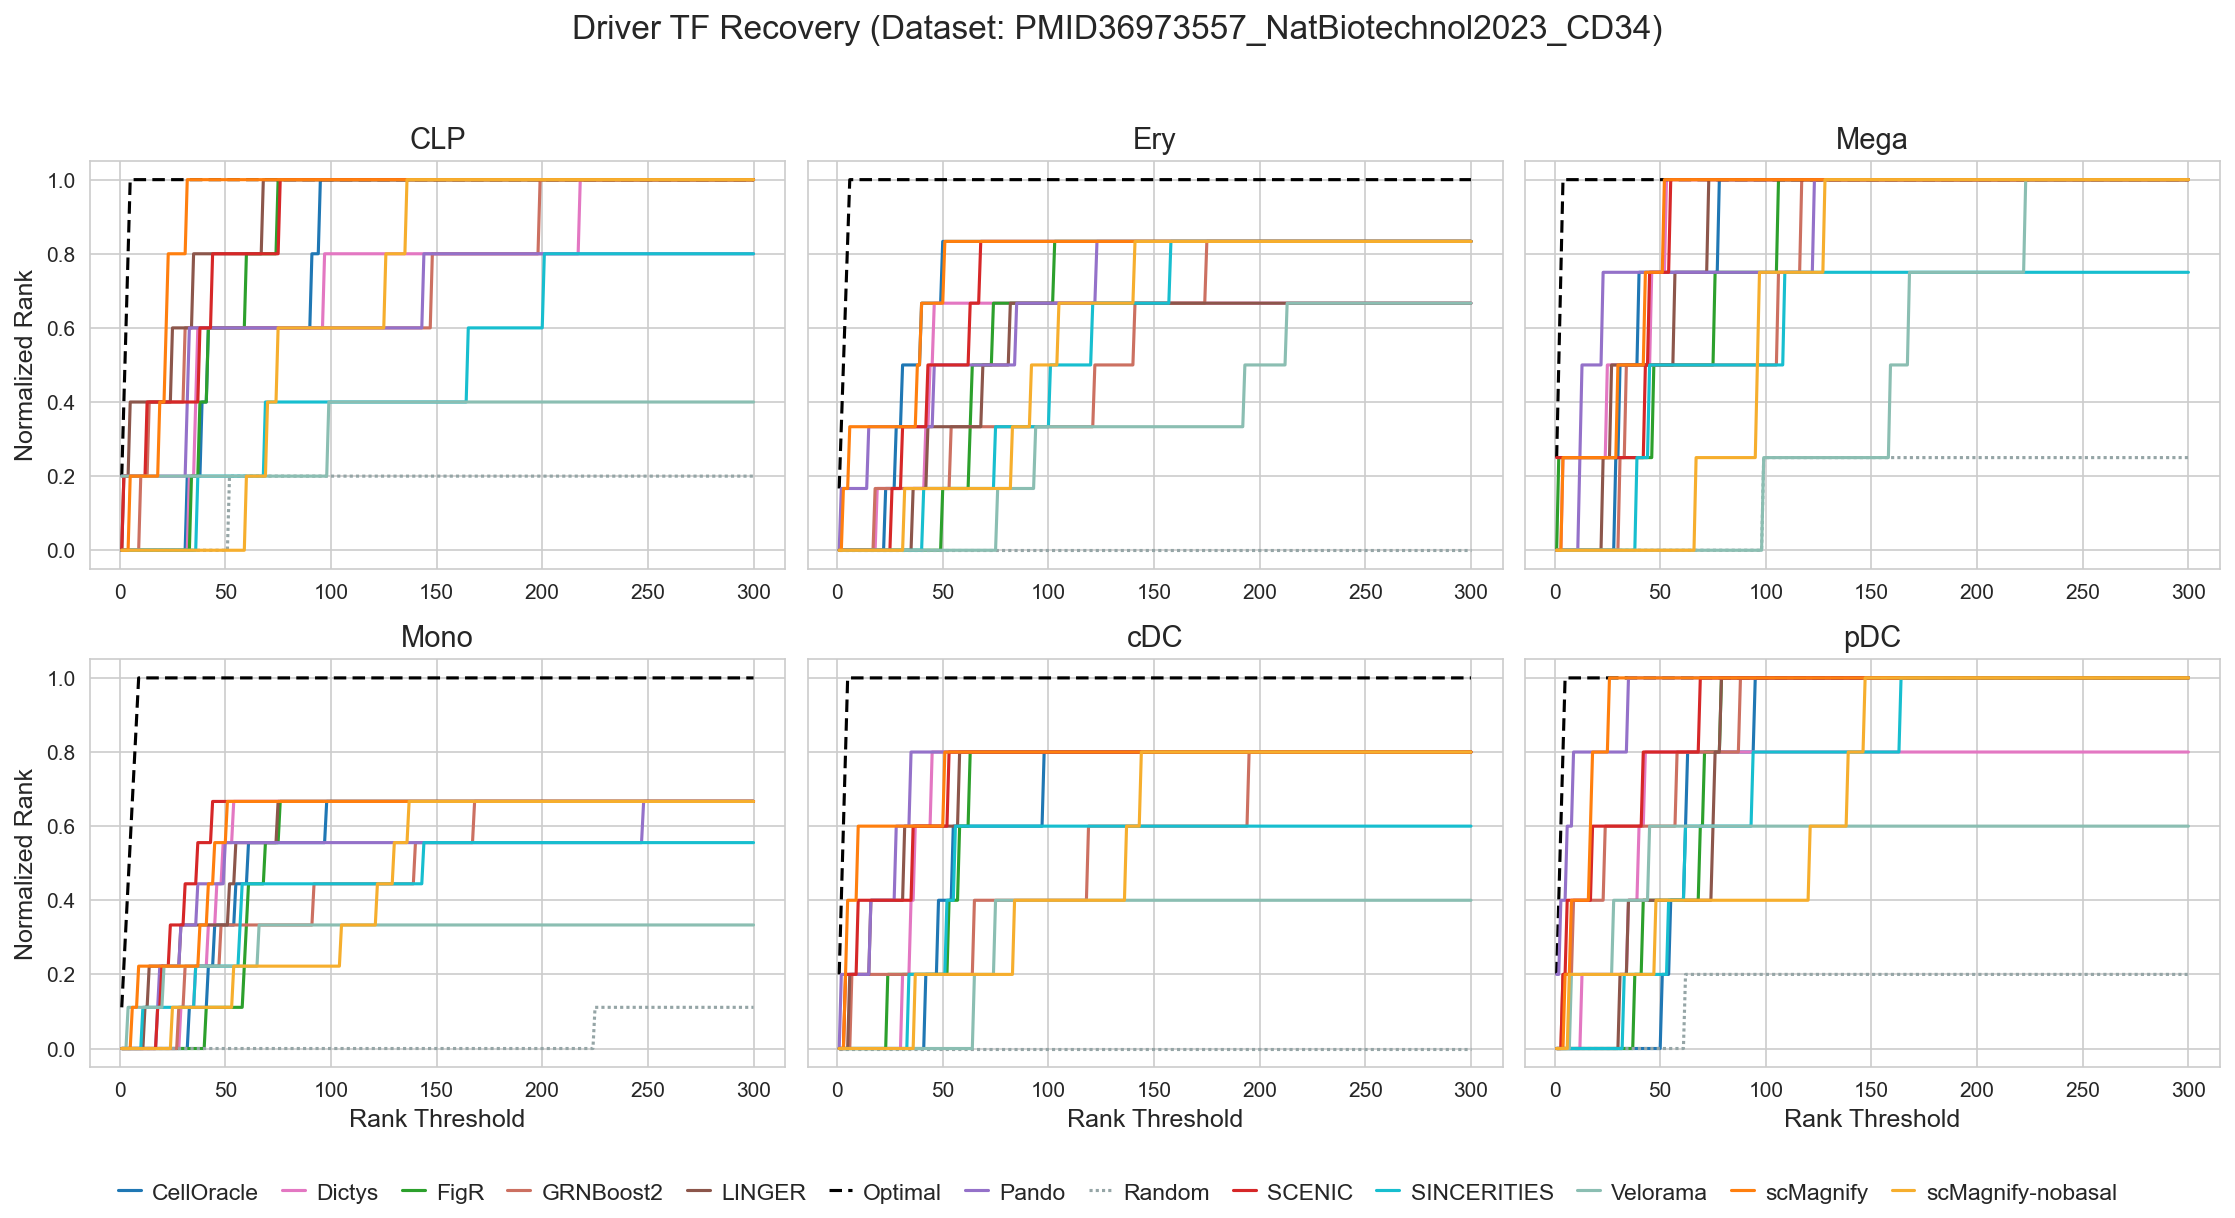

2025-10-19 14:37:18 | [INFO] maxp pruned
2025-10-19 14:37:18 | [INFO] LTSH dropped
2025-10-19 14:37:18 | [INFO] cmap pruned
2025-10-19 14:37:18 | [INFO] kern pruned
2025-10-19 14:37:18 | [INFO] post pruned
2025-10-19 14:37:18 | [INFO] PCLT dropped
2025-10-19 14:37:18 | [INFO] DSIG dropped
2025-10-19 14:37:18 | [INFO] glyf pruned
2025-10-19 14:37:18 | [INFO] Added gid0 to subset
2025-10-19 14:37:18 | [INFO] Added first four glyphs to subset
2025-10-19 14:37:18 | [INFO] Closing glyph list over 'glyf': 57 glyphs before
2025-10-19 14:37:18 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'a', 'b', 'c', 'colon', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'v', 'y', 'z', 'zero']
2025-10-19 14:37:18 | [INFO] Glyph IDs:   [0, 1, 2,

In [26]:
geval.plot_recovery_curves(
    geval.rank_cdf.query("Dataset == 'PMID36973557_NatBiotechnol2023_CD34'"),
    ncols=3,
    save=os.path.join(fig_dir, "SupFig4-tf_recovery_cd34_all.pdf")
)

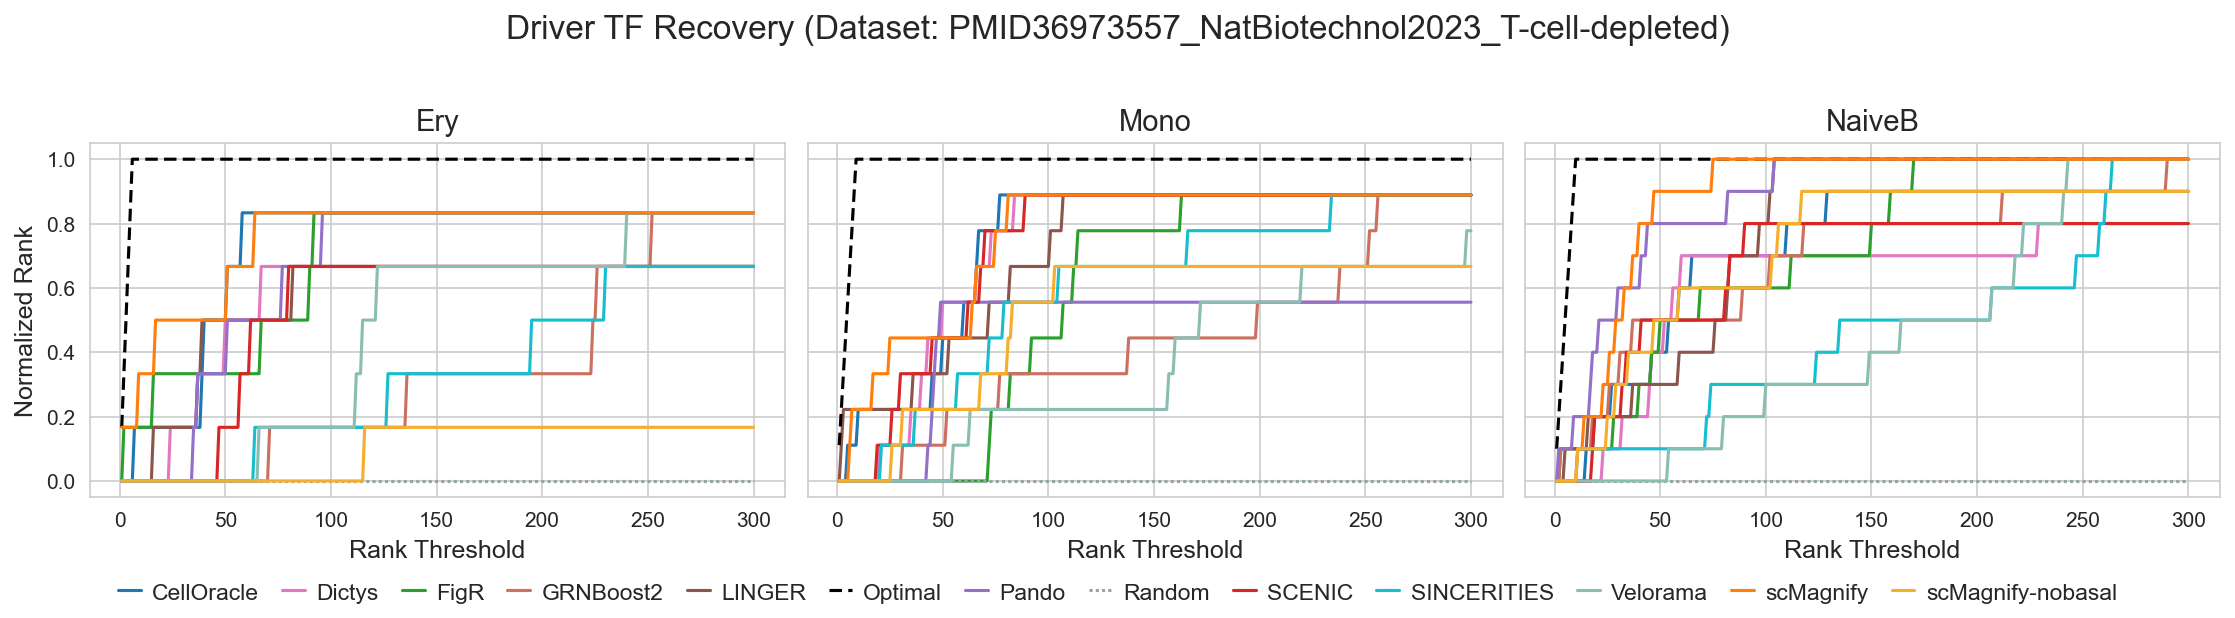

2025-10-19 14:37:21 | [INFO] maxp pruned
2025-10-19 14:37:21 | [INFO] LTSH dropped
2025-10-19 14:37:21 | [INFO] cmap pruned
2025-10-19 14:37:21 | [INFO] kern pruned
2025-10-19 14:37:21 | [INFO] post pruned
2025-10-19 14:37:21 | [INFO] PCLT dropped
2025-10-19 14:37:21 | [INFO] DSIG dropped
2025-10-19 14:37:21 | [INFO] glyf pruned
2025-10-19 14:37:21 | [INFO] Added gid0 to subset
2025-10-19 14:37:21 | [INFO] Added first four glyphs to subset
2025-10-19 14:37:21 | [INFO] Closing glyph list over 'glyf': 57 glyphs before
2025-10-19 14:37:21 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'E', 'F', 'G', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'V', 'a', 'b', 'c', 'colon', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'v', 'y', 'z', 'zero']
2025-10-19 14:37:21 | [INFO] Glyph IDs:   [0, 1, 2,

In [27]:
geval.plot_recovery_curves(
    geval.rank_cdf.query("Dataset == 'PMID36973557_NatBiotechnol2023_T-cell-depleted'"),
    ncols=3,
    save=os.path.join(fig_dir, "SupFig4-tf_recovery_tcell_all.pdf")
)

## Save the data

In [28]:
geval.rank_cdf.to_csv(os.path.join(data_dir, "Fig2-tf_recovery_rank_cdf.csv"))
geval.rank_auc.to_csv(os.path.join(data_dir, "Fig2-tf_recovery_rank_auc.csv"))

In [29]:
geval.rank_cdf

,Rank Threshold,Rank CDF,Normalized Rank,Dataset,Algorithm,Lineage
0,1,0,0.0,PMID36973557_NatBiotechnol2023_CD34,CellOracle,CLP
1,2,0,0.0,PMID36973557_NatBiotechnol2023_CD34,CellOracle,CLP
2,3,0,0.0,PMID36973557_NatBiotechnol2023_CD34,CellOracle,CLP
3,4,0,0.0,PMID36973557_NatBiotechnol2023_CD34,CellOracle,CLP
4,5,0,0.0,PMID36973557_NatBiotechnol2023_CD34,CellOracle,CLP
...,...,...,...,...,...,...
35095,296,9,0.9,PMID36973557_NatBiotechnol2023_T-cell-depleted,scMagnify-nobasal,NaiveB
35096,297,9,0.9,PMID36973557_NatBiotechnol2023_T-cell-depleted,scMagnify-nobasal,NaiveB
35097,298,9,0.9,PMID36973557_NatBiotechnol2023_T-cell-depleted,scMagnify-nobasal,NaiveB
35098,299,9,0.9,PMID36973557_NatBiotechnol2023_T-cell-depleted,scMagnify-nobasal,NaiveB


In [30]:
output_xlsx = os.path.join(data_dir, "SourceDataFig2ef.xlsx")

with pd.ExcelWriter(output_xlsx, engine='xlsxwriter') as writer:
    geval.rank_cdf.query("Lineage == 'NaiveB'").to_excel(writer, sheet_name='Fig2f', index=False)
    geval.rank_auc.to_excel(writer, sheet_name='Fig2e', index=False)